# General Data Analysis

This notebook scans the contents of `data/`, loads each table, and runs a reusable exploratory analysis workflow.

It includes:
- dataset inventory and quick previews
- missingness, numeric, and categorical summaries for every table
- lightweight plotting helpers
- a focused section for `players_quarters_final.csv`, which is the main contest dataset


In [1]:
from pathlib import Path
from typing import Dict

import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
plt.style.use("ggplot")

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
assert DATA_DIR.exists(), f"Missing data directory: {DATA_DIR}"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")


Project root: /Users/jan/Documents/competitions/hackatons/WEC_26
Data directory: /Users/jan/Documents/competitions/hackatons/WEC_26/data


In [2]:
def load_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".csv":
        df = pd.read_csv(path)
    elif suffix == ".parquet":
        df = pd.read_parquet(path)
    elif suffix in {".xlsx", ".xls"}:
        df = pd.read_excel(path)
    else:
        raise ValueError(f"Unsupported file type: {path}")

    for col in df.select_dtypes(include="object").columns:
        non_null = df[col].dropna()
        if non_null.empty:
            continue
        values = set(non_null.astype(str).str.strip().str.lower().unique())
        if values <= {"true", "false"}:
            df[col] = df[col].astype(str).str.strip().str.lower().map({"true": True, "false": False})
    return df


def build_inventory(data_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(data_dir.iterdir()):
        if not path.is_file():
            continue
        if path.suffix.lower() not in {".csv", ".parquet", ".xlsx", ".xls"}:
            continue
        df = load_table(path)
        rows.append(
            {
                "file_name": path.name,
                "format": path.suffix.lower().lstrip("."),
                "rows": len(df),
                "columns": df.shape[1],
                "size_mb": round(path.stat().st_size / (1024 ** 2), 3),
            }
        )
    return pd.DataFrame(rows).sort_values(["rows", "file_name"], ascending=[False, True]).reset_index(drop=True)


def dataset_overview(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=True),
    })
    return out.sort_values(["missing_pct", "unique"], ascending=[False, False])


def numeric_summary(df: pd.DataFrame) -> pd.DataFrame:
    num = df.select_dtypes(include=np.number)
    if num.empty:
        return pd.DataFrame()
    summary = num.describe().T
    summary["missing"] = df[num.columns].isna().sum()
    summary["missing_pct"] = (df[num.columns].isna().mean() * 100).round(2)
    return summary.sort_values("std", ascending=False)


def categorical_summary(df: pd.DataFrame, top_n: int = 8) -> Dict[str, pd.DataFrame]:
    result = {}
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    for col in cat_cols:
        counts = df[col].fillna("<NA>").value_counts(dropna=False).head(top_n)
        result[col] = pd.DataFrame({
            "count": counts,
            "pct": (counts / len(df) * 100).round(2),
        })
    return result


def plot_top_missing(df: pd.DataFrame, title: str, top_n: int = 15) -> None:
    missing = (df.isna().mean() * 100).sort_values(ascending=False).head(top_n)
    if missing.max() == 0:
        print("No missing values in this table.")
        return
    ax = missing.sort_values().plot(kind="barh", figsize=(8, max(4, top_n * 0.35)), color="#C44E52")
    ax.set_title(f"Top Missingness: {title}")
    ax.set_xlabel("Missing values (%)")
    ax.set_ylabel("")
    plt.show()


def plot_numeric_distributions(df: pd.DataFrame, title: str, max_cols: int = 6) -> None:
    num_cols = df.select_dtypes(include=np.number).columns.tolist()[:max_cols]
    if not num_cols:
        print("No numeric columns to plot.")
        return
    ncols = 2
    nrows = math.ceil(len(num_cols) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, num_cols):
        df[col].dropna().plot(kind="hist", bins=30, ax=ax, color="#4C72B0", alpha=0.8)
        ax.set_title(col)
    for ax in axes[len(num_cols):]:
        ax.axis("off")
    fig.suptitle(f"Numeric Distributions: {title}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()


In [3]:
inventory = build_inventory(DATA_DIR)
tables = {
    path.name: load_table(path)
    for path in sorted(DATA_DIR.iterdir())
    if path.is_file() and path.suffix.lower() in {".csv", ".parquet", ".xlsx", ".xls"}
}

display(Markdown("## Data Inventory"))
display(inventory)

display(Markdown("## Quick Preview"))
for name, df in tables.items():
    display(Markdown(f"### `{name}`"))
    print(f"shape = {df.shape}")
    display(df.head())


## Data Inventory

,file_name,format,rows,columns,size_mb
0,player_appearance_run.csv,csv,35133,10,2.623
1,player_appearance_pass.csv,csv,29795,7,1.292
2,player_appearance_behaviour_under_pressure.csv,csv,12185,10,0.907
3,players_quarters_final.csv,csv,3486,33,0.437
4,player_appearance_shot_limited.csv,csv,780,12,0.067


## Quick Preview

### `player_appearance_behaviour_under_pressure.csv`

shape = (12185, 10)


...

shape = (780, 12)


,id,period,player_appearance_id,body_part,technique,play_pattern,own_goal_player_appearance_id,block_player_appearance_id,minute,possession,stage,under_pressure
0,143,half_1,39442,right_foot,normal,regular_play,NaN,NaN,11,2285,top,False
1,144,half_1,39442,right_foot,normal,counter_attack,NaN,39422.0,31,2285,top,True
2,145,half_1,39440,head,normal,regular_play,NaN,NaN,16,2285,top,True
3,146,half_2,39440,head,lob,corner_kick,NaN,NaN,45,2285,top,True
4,147,half_1,39438,right_foot,normal,regular_play,NaN,NaN,16,2285,top,True


### `players_quarters_final.csv`

shape = (3486, 33)


,player_appearance_id,player_id,fixture_id,date,checkpoint,checkpoint_period,checkpoint_min,position,is_home,formation,minute_in,minute_out,subbed,jersey_number,last15_sprints,last15_hsr,last15_distance,last15_mean_max_speed,last15_peak_speed,last15_shots,last15_shots_on_target,last15_shots_under_press,last15_shots_top_third,cumul_sprints,cumul_hsr,cumul_distance,cumul_mean_max_speed,cumul_peak_speed,cumul_shots,cumul_shots_on_target,cumul_shots_under_press,cumul_shots_top_third,scored_after
0,39421,2702,1159,2025-06-11,H1_15,half_1,15,G,True,4-1-4-1,1,90,False,1,0,0,0.00,0.000,0.00,0,0,0,0,0,0,0.00,0.000,0.00,0,0,0,0,0
1,39422,2732,1159,2025-06-11,H1_15,half_1,15,D,True,4-1-4-1,1,90,False,2,2,5,68.15,6.806,7.46,0,0,0,0,2,5,68.15,6.806,7.46,0,0,0,0,0
2,39423,3296,1159,2025-06-11,H1_15,half_1,15,D,True,4-1-4-1,1,90,False,4,2,4,68.49,7.165,7.87,0,0,0,0,2,4,68.49,7.165,7.87,0,0,0,0,0
3,39424,3297,1159,2025-06-11,H1_15,half_1,15,D,True,4-1-4-1,1,90,False,5,1,5,80.36,6.873,8.95,0,0,0,0,1,5,80.36,6.873,8.95,0,0,0,0,0
4,39425,3298,1159,2025-06-11,H1_15,half_1,15,A,True,4-1-4-1,1,75,True,6,4,15,183.30,6.533,7.68,0,0,0,0,4,15,183.30,6.533,7.68,0,0,0,0,0


## Overview: `player_appearance_behaviour_under_pressure.csv`

,dtype,non_null,missing,missing_pct,unique
pass_angle,float64,6392,5793,47.54,6391
addressee_player_appearance_id,float64,11536,649,5.33,938
stage,object,12171,14,0.11,3
id,int64,12185,0,0.00,12185
player_appearance_id,int64,12185,0,0.00,923
pressing_player_appearance_id,int64,12185,0,0.00,895
minute,int64,12185,0,0.00,55
press_induced_outcome,object,12185,0,0.00,5
period,object,12185,0,0.00,4
accurate,bool,12185,0,0.00,2


### Numeric Summary

,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
id,12185.0,262772.758391,55330.525772,232693.000000,236869.000000,247851.000000,255062.000000,439291.000000,0,0.00
player_appearance_id,12185.0,43195.661551,7074.127626,39422.000000,39896.000000,41328.000000,42180.000000,65790.000000,0,0.00
pressing_player_appearance_id,12185.0,43196.638408,7073.975707,39422.000000,39898.000000,41330.000000,42181.000000,65790.000000,0,0.00
addressee_player_appearance_id,11536.0,43196.484050,7071.413838,39421.000000,39896.000000,41330.500000,42179.000000,65790.000000,649,5.33
pass_angle,6392.0,-1.275053,50.317946,-89.817743,-44.241927,-2.882948,41.706772,89.992683,5793,47.54
minute,12185.0,23.477144,14.073072,1.000000,11.000000,23.000000,35.000000,56.000000,0,0.00


### Top Categories

...

,count,pct
accurate,,
True,6950,57.04
False,5235,42.96


**press_induced_outcome**

,count,pct
press_induced_outcome,,
turnover,4763,39.09
backward_pass,3213,26.37
forward_pass,2274,18.66
ball_carry,1030,8.45
lateral_pass,905,7.43


**stage**

,count,pct
stage,,
middle,5492,45.07
top,4076,33.45
bottom,2603,21.36
<NA>,14,0.11


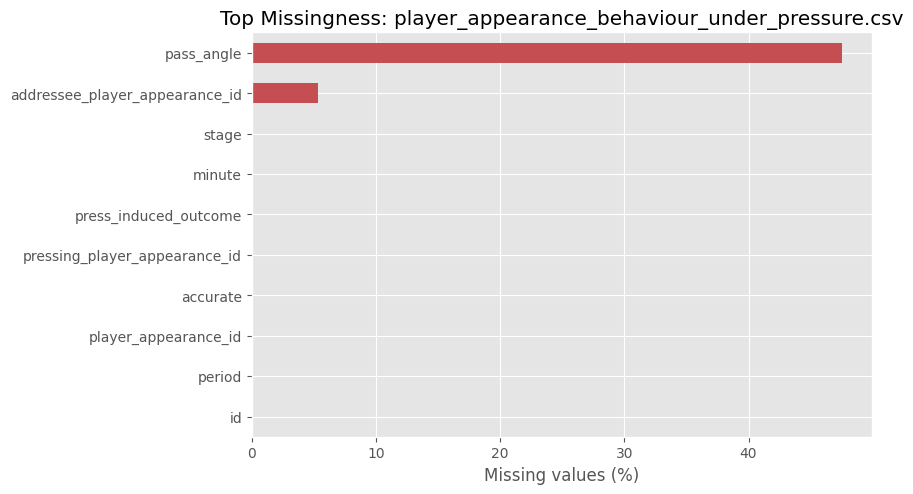

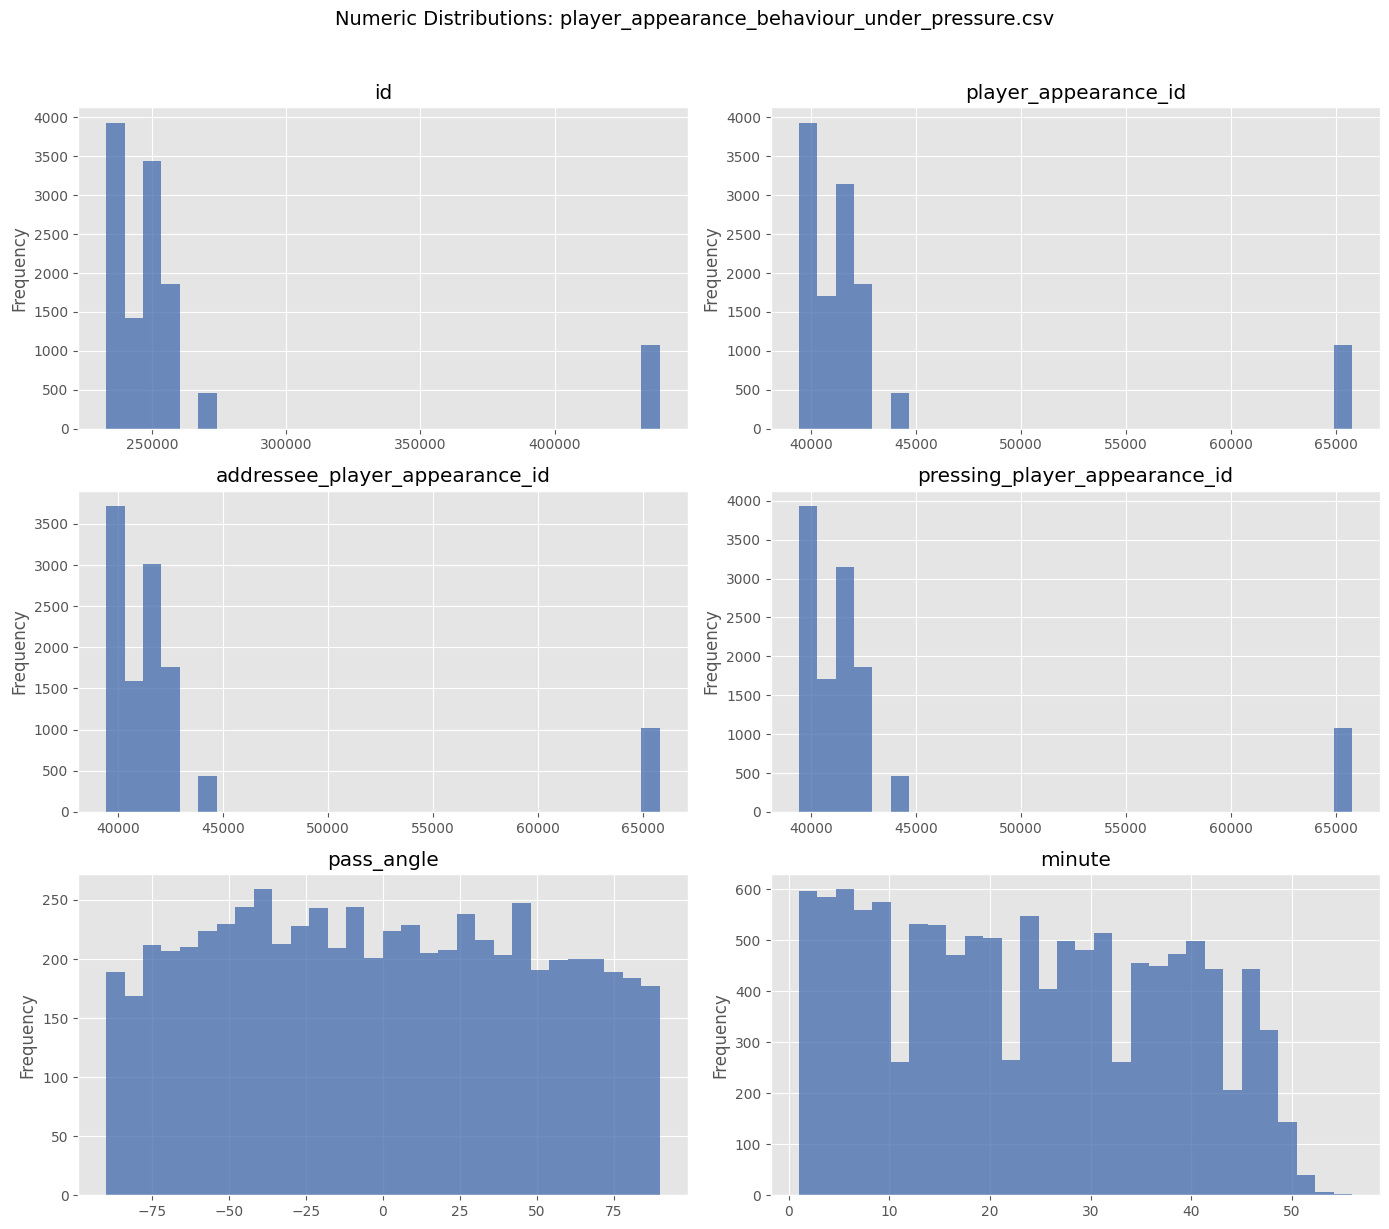

## Overview: `player_appearance_pass.csv`

,dtype,non_null,missing,missing_pct,unique
stage,object,29738,57,0.19,3
addressee_player_appearance_id,float64,29754,41,0.14,968
id,int64,29795,0,0.00,29795
player_appearance_id,int64,29795,0,0.00,959
minute,int64,29795,0,0.00,56
period,object,29795,0,0.00,4
accurate,bool,29795,0,0.00,2


### Numeric Summary

,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
id,29795.0,876152.631851,184404.162633,787100.0,797205.5,824909.0,841755.5,1467414.0,0,0.00
player_appearance_id,29795.0,43134.044873,7087.330409,39421.0,39880.0,41249.0,42162.5,65790.0,0,0.00
addressee_player_appearance_id,29754.0,43103.172783,7042.912687,39421.0,39880.0,41249.0,42160.0,65790.0,41,0.14
minute,29795.0,23.450915,14.128491,1.0,11.0,23.0,35.0,57.0,0,0.00


### Top Categories

...

,count,pct
period,,
half_1,15708,52.72
half_2,13488,45.27
extra_time_1,308,1.03
extra_time_2,291,0.98


**accurate**

,count,pct
accurate,,
True,24961,83.78
False,4834,16.22


**stage**

,count,pct
stage,,
middle,14369,48.23
bottom,8733,29.31
top,6636,22.27
<NA>,57,0.19


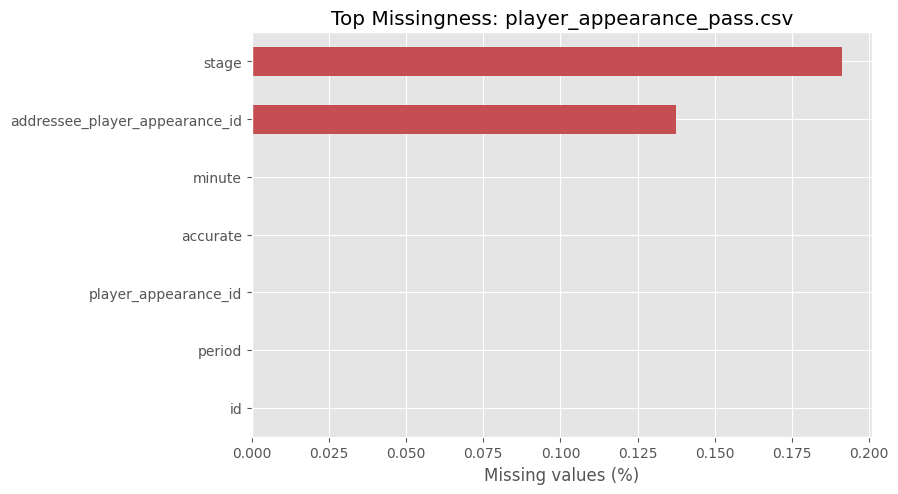

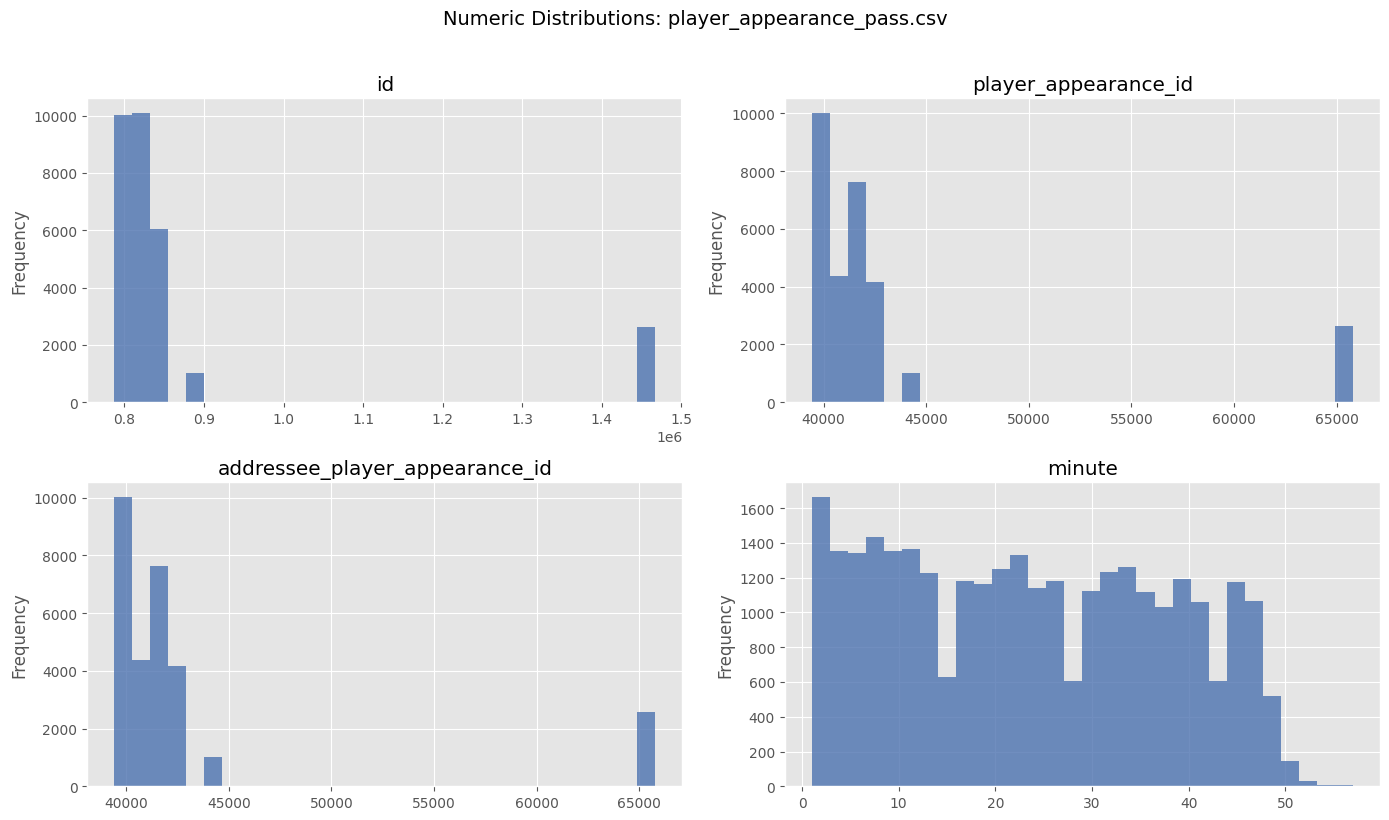

## Overview: `player_appearance_run.csv`

,dtype,non_null,missing,missing_pct,unique
id,int64,35133,0,0.0,35133
distance,float64,35133,0,0.0,33613
player_appearance_id,int64,35133,0,0.0,968
max_speed,float64,35133,0,0.0,489
min_speed,float64,35133,0,0.0,297
possession,int64,35133,0,0.0,62
minute,int64,35133,0,0.0,57
period,object,35133,0,0.0,4
stage,object,35133,0,0.0,3
run_type,object,35133,0,0.0,2


### Numeric Summary

,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
id,35133.0,775001.550366,191154.974220,672855.000000,685114.000000,713687.000000,738717.000000,1327420.000,0,0.0
player_appearance_id,35133.0,43607.726126,7665.209830,39421.000000,39900.000000,41265.000000,42196.000000,65790.000,0,0.0
possession,35133.0,2503.625993,433.723947,2284.000000,2305.000000,2367.000000,2412.000000,3761.000,0,0.0
distance,35133.0,47.927390,121.727855,2.892288,7.719496,12.074841,19.954639,1694.008,0,0.0
minute,35133.0,23.635699,14.470166,1.000000,11.000000,23.000000,36.000000,59.000,0,0.0
min_speed,35133.0,5.351574,0.895170,0.290000,5.390000,5.510000,5.540000,7.280,0,0.0
max_speed,35133.0,6.717121,0.798054,5.440000,6.060000,6.720000,7.000000,14.140,0,0.0


### Top Categories

...

**stage**

,count,pct
stage,,
middle,14874,42.34
top,10671,30.37
bottom,9588,27.29


**run_type**

,count,pct
run_type,,
hsr,28417,80.88
sprint,6716,19.12


No missing values in this table.


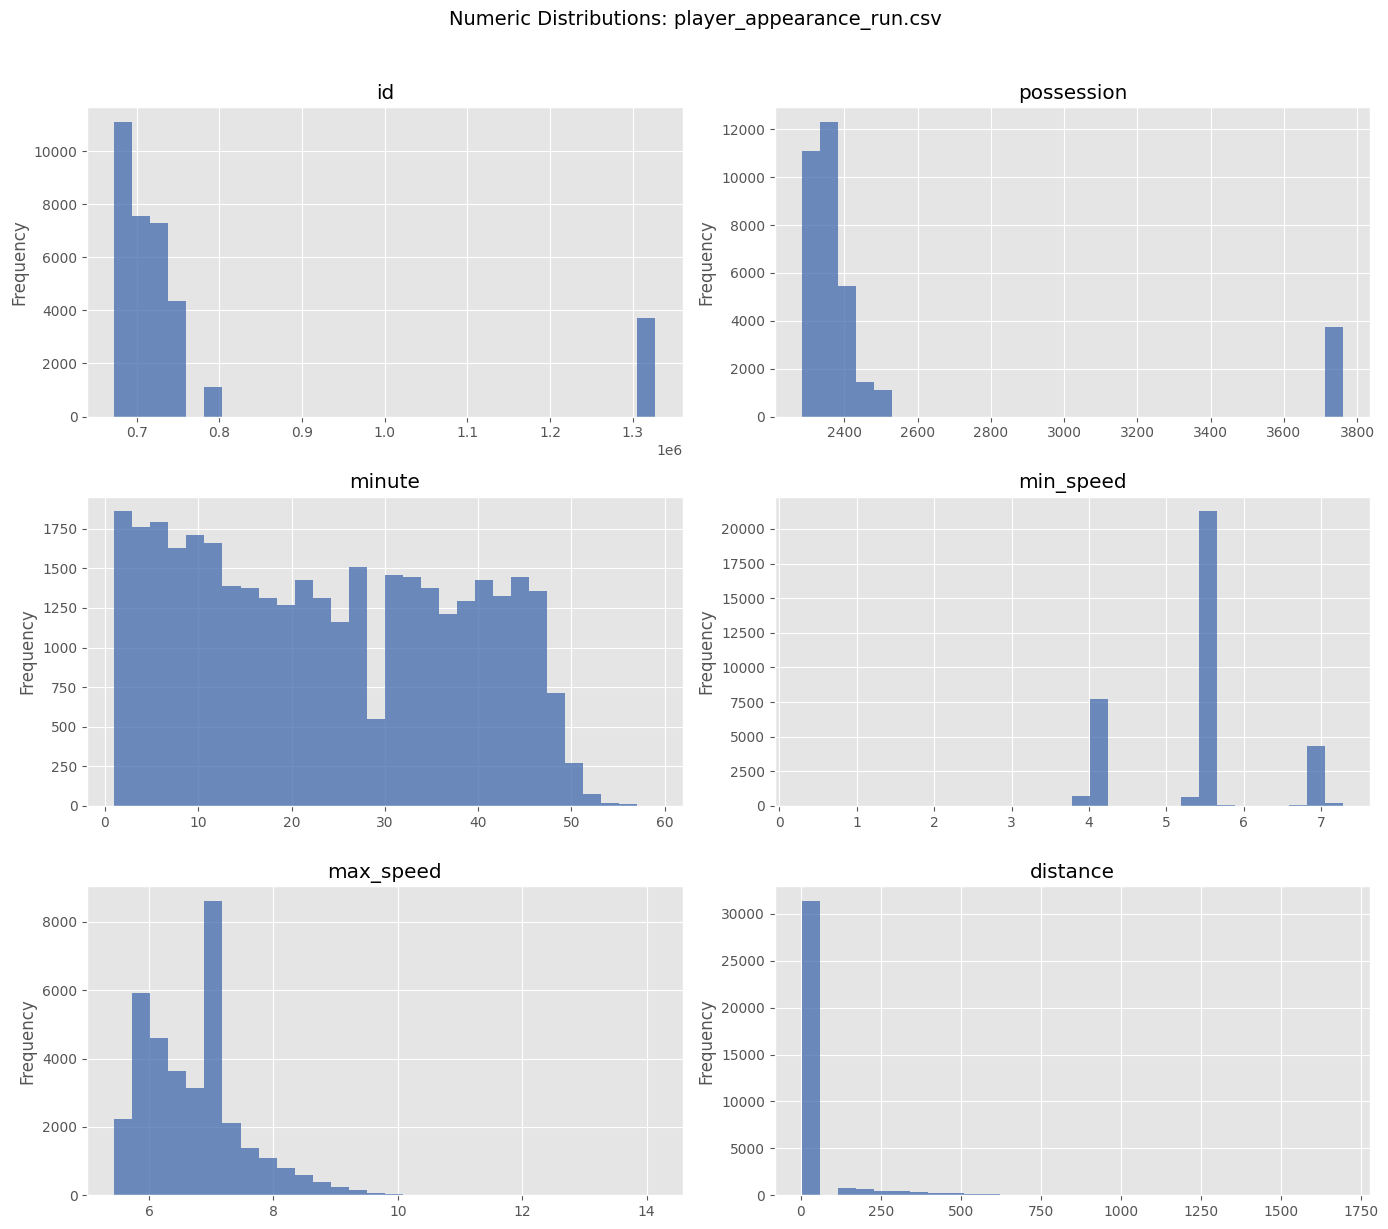

## Overview: `player_appearance_shot_limited.csv`

,dtype,non_null,missing,missing_pct,unique
own_goal_player_appearance_id,float64,1,779,99.87,1
block_player_appearance_id,float64,215,565,72.44,172
id,int64,780,0,0.00,780
player_appearance_id,int64,780,0,0.00,453
possession,int64,780,0,0.00,62
minute,int64,780,0,0.00,53
play_pattern,object,780,0,0.00,7
technique,object,780,0,0.00,5
period,object,780,0,0.00,4
body_part,object,780,0,0.00,4


### Numeric Summary

,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
player_appearance_id,780.0,43202.910256,7084.092993,39426.0,39931.00,41263.5,42169.50,65789.0,0,0.00
block_player_appearance_id,215.0,42703.558140,6407.125363,39422.0,39899.00,41163.0,41912.00,65789.0,565,72.44
id,780.0,1213.876923,899.350326,143.0,395.75,1109.5,1632.25,3510.0,0,0.00
possession,780.0,2480.284615,400.608034,2284.0,2306.00,2367.0,2411.00,3761.0,0,0.00
minute,780.0,25.237179,14.235283,1.0,13.00,25.0,38.00,57.0,0,0.00
own_goal_player_appearance_id,1.0,41169.000000,NaN,41169.0,41169.00,41169.0,41169.00,41169.0,779,99.87


### Top Categories

...

,count,pct
play_pattern,,
regular_play,543,69.62
corner_kick,84,10.77
counter_attack,60,7.69
indirect_free_kick,36,4.62
direct_free_kick,26,3.33
throw_in,21,2.69
penalty,10,1.28


**stage**

,count,pct
stage,,
top,748,95.90
middle,21,2.69
bottom,11,1.41


**under_pressure**

,count,pct
under_pressure,,
True,607,77.82
False,173,22.18


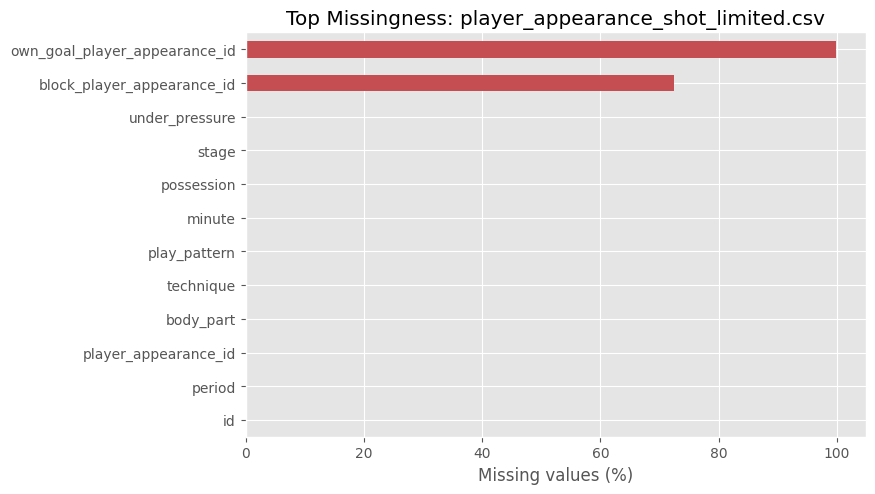

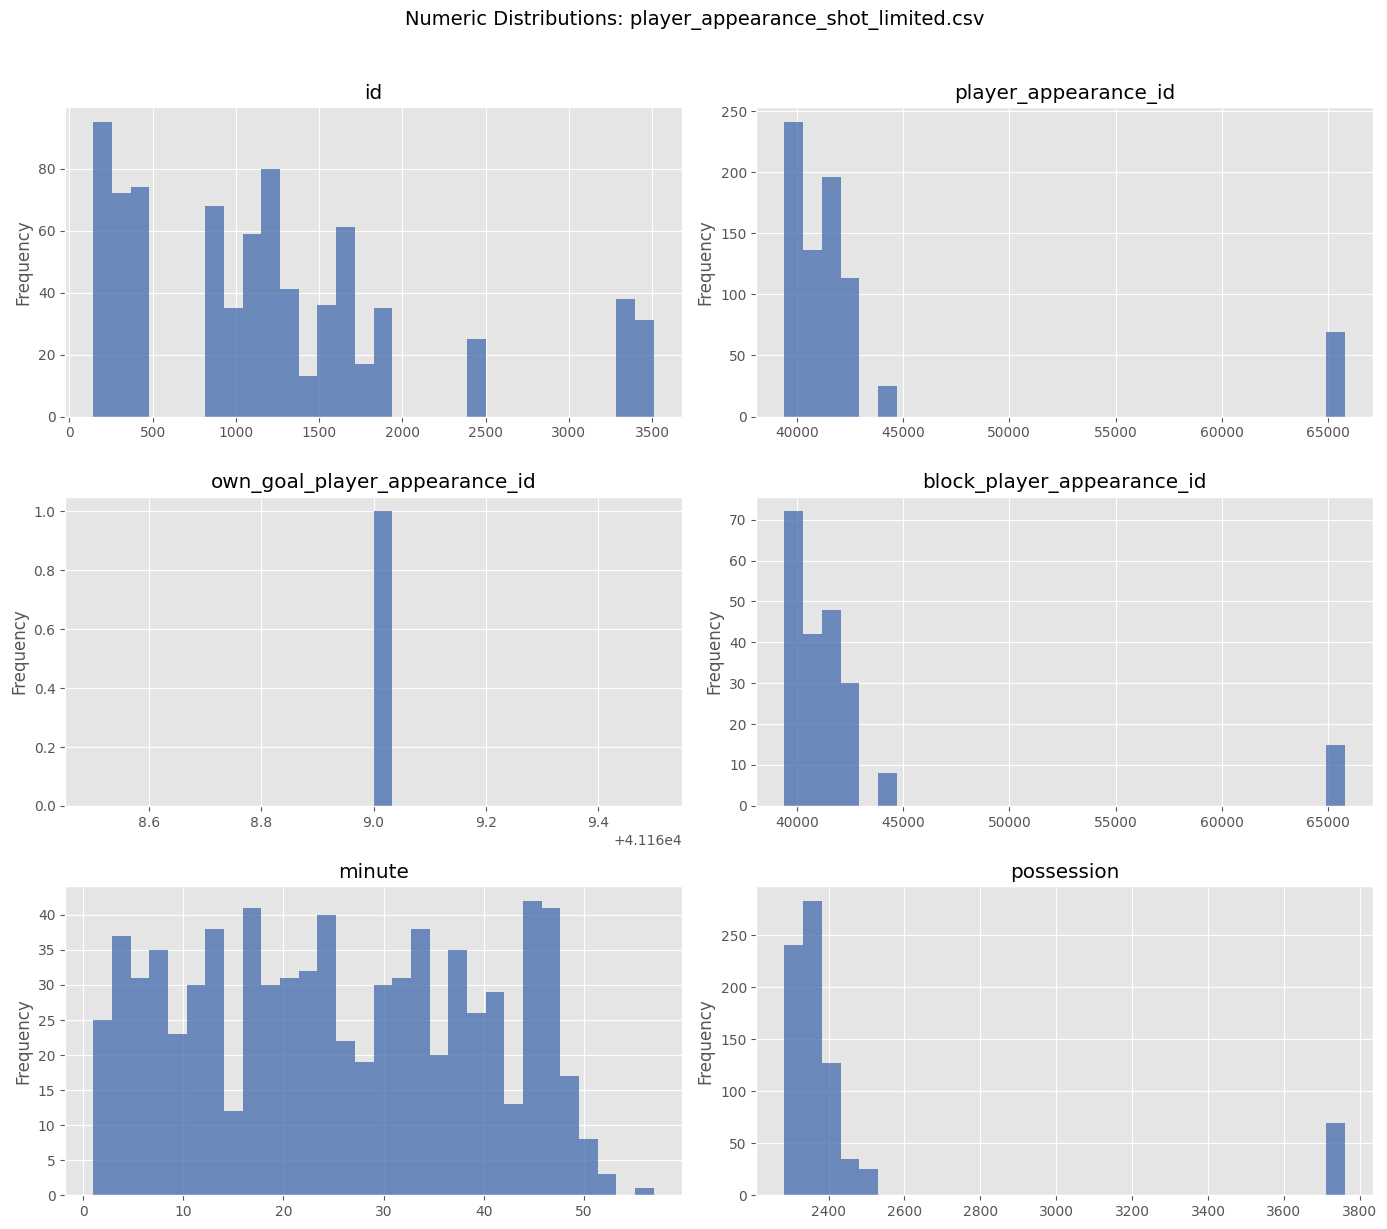

## Overview: `players_quarters_final.csv`

,dtype,non_null,missing,missing_pct,unique
cumul_distance,float64,3486,0,0.0,3188
last15_distance,float64,3486,0,0.0,3054
last15_mean_max_speed,float64,3486,0,0.0,1276
cumul_mean_max_speed,float64,3486,0,0.0,1049
player_appearance_id,int64,3486,0,0.0,869
last15_peak_speed,float64,3486,0,0.0,447
cumul_peak_speed,float64,3486,0,0.0,409
player_id,int64,3486,0,0.0,307
cumul_hsr,int64,3486,0,0.0,70
minute_out,int64,3486,0,0.0,50


### Numeric Summary

,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
player_appearance_id,3486.0,43340.148021,7293.655098,39421.0,39905.0000,41263.000,42180.00000,65789.00,0,0.0
cumul_distance,3486.0,969.208127,2701.188546,0.0,138.4775,277.835,490.50500,25667.77,0,0.0
last15_distance,3486.0,367.125017,978.769500,0.0,59.5025,107.195,164.18000,8028.31,0,0.0
player_id,3486.0,3096.829317,688.829308,400.0,3299.0000,3400.000,3499.00000,3582.00,0,0.0
fixture_id,3486.0,1191.443201,23.448899,1159.0,1166.0000,1191.000,1207.00000,1237.00,0,0.0
minute_in,3486.0,5.541882,16.228174,1.0,1.0000,1.000,1.00000,102.00,0,0.0
minute_out,3486.0,85.528399,13.867012,21.0,81.0000,90.000,90.00000,120.00,0,0.0
cumul_hsr,3486.0,18.144291,12.880450,0.0,8.0000,16.000,26.00000,80.00,0,0.0
checkpoint_min,3486.0,27.074010,11.344418,15.0,15.0000,30.000,30.00000,45.00,0,0.0
jersey_number,3486.0,10.138554,6.515054,1.0,4.0000,9.000,16.00000,23.00,0,0.0


### Top Categories

...

**formation**

,count,pct
formation,,
4-2-3-1,953,27.34
4-3-3,825,23.67
4-4-2,539,15.46
4-1-4-1,490,14.06
3-4-3,330,9.47
5-4-1,110,3.16
3-4-2-1,74,2.12
4-1-3-2,55,1.58


**subbed**

,count,pct
subbed,,
False,2228,63.91
True,1258,36.09


No missing values in this table.


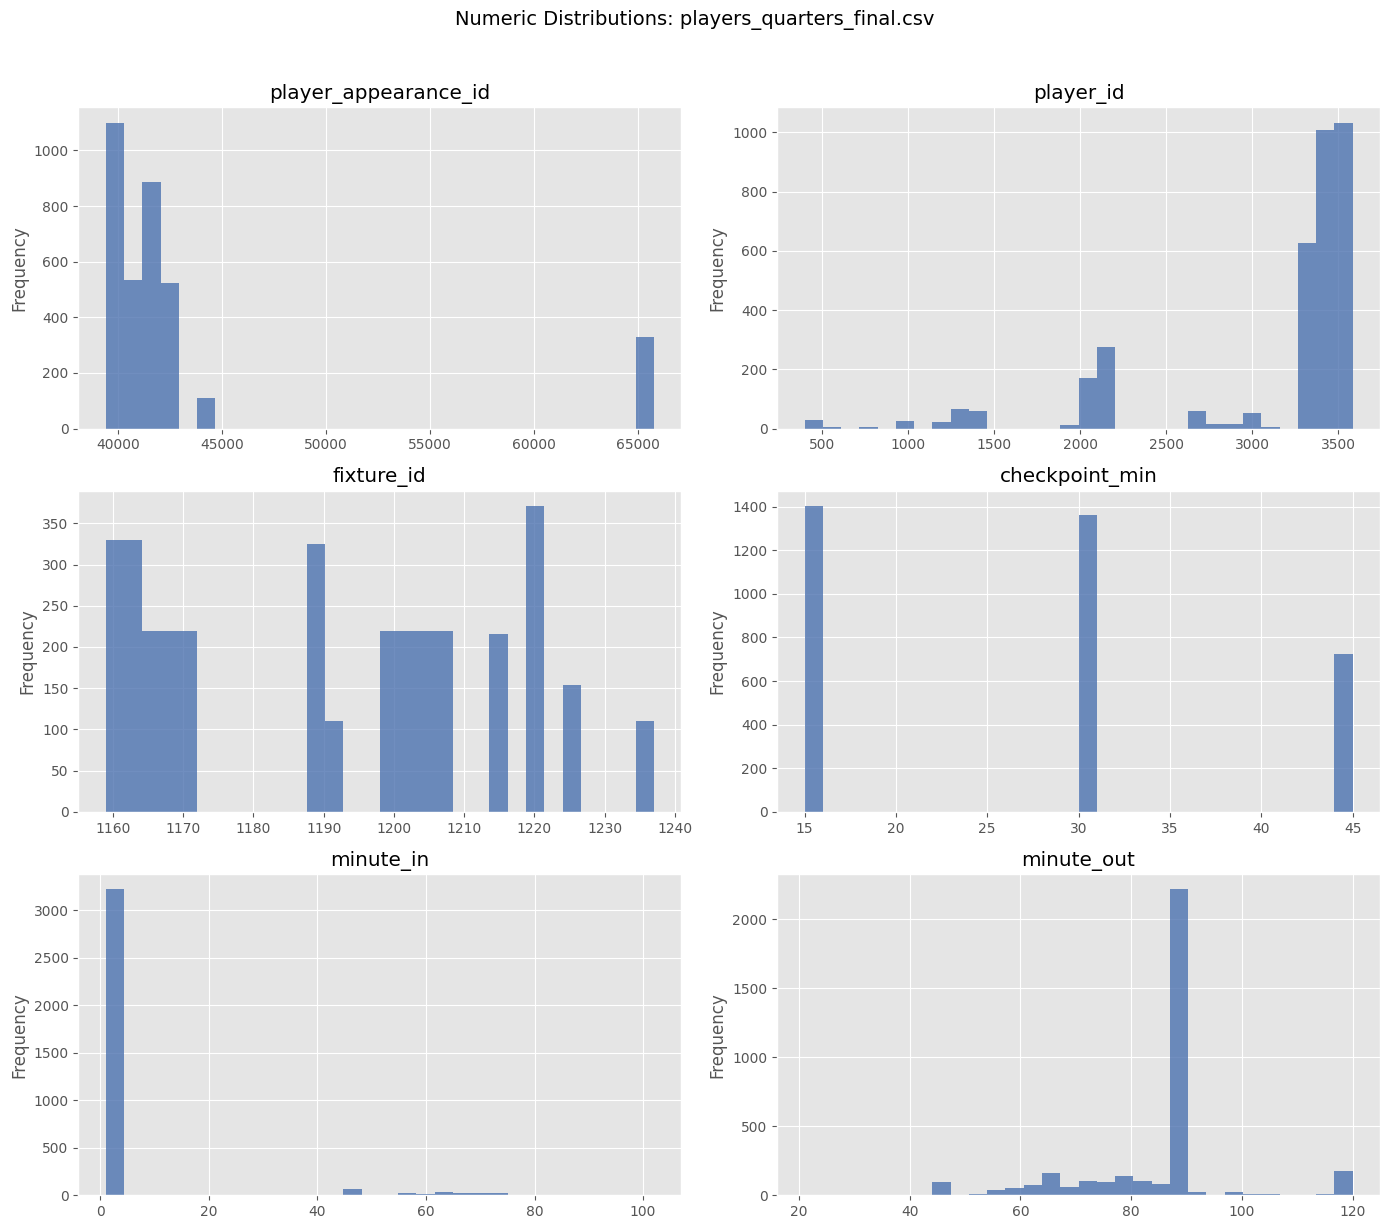

In [4]:
for name, df in tables.items():
    display(Markdown(f"## Overview: `{name}`"))
    display(dataset_overview(df))

    num_summary = numeric_summary(df)
    if not num_summary.empty:
        display(Markdown("### Numeric Summary"))
        display(num_summary)

    cat_summary = categorical_summary(df)
    if cat_summary:
        display(Markdown("### Top Categories"))
        for col, summary in cat_summary.items():
            display(Markdown(f"**{col}**"))
            display(summary)

    plot_top_missing(df, name)
    plot_numeric_distributions(df, name)


## Contest-Aware Analysis: `players_quarters_final.csv`

The documentation in `docs/` frames `players_quarters_final.csv` as the main modeling table:

- one row = one player snapshot at a 15-minute checkpoint within a match
- documented scope: `3,486` rows, `31` matches, `869` player appearances
- target `scored_after` is rare by construction, because goals after a checkpoint are rare events
- `last15_` and `cumul_` features come only from the run and shot source tables
- pass and behaviour-under-pressure tables were **not** used in the base panel and are available for extension
- shot outcome was intentionally removed from the contest version of the shot table to avoid leakage

The cells below turn those documentation details into explicit dataset checks and modeling-oriented EDA.


In [5]:
main_df = tables["players_quarters_final.csv"].copy()
main_df["date"] = pd.to_datetime(main_df["date"])

checkpoint_order = ["H1_15", "H1_30", "H1_45", "H2_15", "H2_30", "H2_45", "ET1_15"]
checkpoint_to_abs_min = {
    "H1_15": 15,
    "H1_30": 30,
    "H1_45": 45,
    "H2_15": 60,
    "H2_30": 75,
    "H2_45": 90,
    "ET1_15": 105,
}
interval_index = {checkpoint: idx + 1 for idx, checkpoint in enumerate(checkpoint_order)}
feature_families = [
    ("sprints", "last15_sprints", "cumul_sprints"),
    ("hsr", "last15_hsr", "cumul_hsr"),
    ("distance", "last15_distance", "cumul_distance"),
    ("mean_max_speed", "last15_mean_max_speed", "cumul_mean_max_speed"),
    ("peak_speed", "last15_peak_speed", "cumul_peak_speed"),
    ("shots", "last15_shots", "cumul_shots"),
    ("shots_on_target", "last15_shots_on_target", "cumul_shots_on_target"),
    ("shots_under_press", "last15_shots_under_press", "cumul_shots_under_press"),
    ("shots_top_third", "last15_shots_top_third", "cumul_shots_top_third"),
]

main_df["checkpoint"] = pd.Categorical(main_df["checkpoint"], categories=checkpoint_order, ordered=True)
main_df["checkpoint_abs_min"] = main_df["checkpoint"].astype(str).map(checkpoint_to_abs_min)
main_df["interval_idx"] = main_df["checkpoint"].astype(str).map(interval_index)
main_df["active_at_checkpoint"] = (
    (main_df["minute_in"] <= main_df["checkpoint_abs_min"])
    & (main_df["minute_out"] >= main_df["checkpoint_abs_min"])
)
main_df["minutes_available_before_checkpoint"] = (
    main_df["checkpoint_abs_min"] - main_df["minute_in"] + 1
).clip(lower=1)
main_df["short_stint_before_checkpoint"] = main_df["minutes_available_before_checkpoint"] < 15

contest_summary = pd.DataFrame(
    [
        {"metric": "rows", "documented": "3,486", "observed": f"{len(main_df):,}"},
        {"metric": "unique matches", "documented": "31", "observed": str(main_df["fixture_id"].nunique())},
        {
            "metric": "unique player appearances",
            "documented": "869",
            "observed": str(main_df["player_appearance_id"].nunique()),
        },
        {
            "metric": "positive target rate",
            "documented": "203 / 3,486 (5.82%)",
            "observed": f"{main_df['scored_after'].sum():,} / {len(main_df):,} ({main_df['scored_after'].mean() * 100:.2f}%)",
        },
        {
            "metric": "rows active at checkpoint",
            "documented": "all rows should satisfy the checkpoint rule",
            "observed": f"{main_df['active_at_checkpoint'].sum():,} / {len(main_df):,}",
        },
        {
            "metric": "rows with <15 minutes available before checkpoint",
            "documented": "possible for recent substitutions",
            "observed": f"{main_df['short_stint_before_checkpoint'].sum():,} ({main_df['short_stint_before_checkpoint'].mean() * 100:.2f}%)",
        },
    ]
)

display(Markdown("### Documentation Consistency Checks"))
display(contest_summary)

checkpoint_profile = (
    main_df.groupby(["checkpoint", "checkpoint_period", "checkpoint_min"], observed=True)
    .agg(
        rows=("player_appearance_id", "size"),
        unique_appearances=("player_appearance_id", "nunique"),
        scored_after_rate=("scored_after", "mean"),
        subbed_share=("subbed", "mean"),
        short_stint_share=("short_stint_before_checkpoint", "mean"),
    )
    .reset_index()
)
checkpoint_profile["share_of_rows_pct"] = checkpoint_profile["rows"] / len(main_df) * 100
checkpoint_profile["scored_after_rate"] = (checkpoint_profile["scored_after_rate"] * 100).round(2)
checkpoint_profile["subbed_share"] = (checkpoint_profile["subbed_share"] * 100).round(2)
checkpoint_profile["short_stint_share"] = (checkpoint_profile["short_stint_share"] * 100).round(2)
checkpoint_profile["share_of_rows_pct"] = checkpoint_profile["share_of_rows_pct"].round(2)
display(Markdown("### Checkpoint Structure"))
display(checkpoint_profile)

context_summary = (
    main_df.groupby(["position", "is_home", "subbed"], observed=False)["scored_after"]
    .agg(["count", "mean"])
    .reset_index()
)
context_summary["mean"] = (context_summary["mean"] * 100).round(2)
context_summary = context_summary.rename(columns={"mean": "scored_after_rate_pct"})
display(Markdown("### Target Rate Across Position, Venue, and Substitution Status"))
display(context_summary.sort_values(["position", "subbed", "is_home"]))


### Documentation Consistency Checks

,metric,documented,observed
0,rows,"3,486","3,486"
1,unique matches,31,31
2,unique player appearances,869,869
3,positive target rate,"203 / 3,486 (5.82%)","203 / 3,486 (5.82%)"
4,rows active at checkpoint,all rows should satisfy the checkpoint rule,"3,486 / 3,486"
5,rows with <15 minutes available before checkpoint,possible for recent substitutions,140 (4.02%)


### Checkpoint Structure

,checkpoint,checkpoint_period,checkpoint_min,rows,unique_appearances,scored_after_rate,subbed_share,short_stint_share,share_of_rows_pct
0,H1_15,half_1,15,681,681,8.96,43.32,0.15,19.54
1,H1_30,half_1,30,680,680,7.06,43.38,0.00,19.51
2,H1_45,half_1,45,680,680,5.74,43.24,0.15,19.51
3,H2_15,half_2,15,680,680,3.97,35.15,3.24,19.51
4,H2_30,half_2,30,680,680,3.68,17.79,15.59,19.51
5,H2_45,half_2,45,43,43,4.65,27.91,9.30,1.23
6,ET1_15,extra_time_1,15,42,42,2.38,4.76,14.29,1.20


### Target Rate Across Position, Venue, and Substitution Status

,position,is_home,subbed,count,scored_after_rate_pct
0,A,False,False,119,15.13
2,A,True,False,113,12.39
1,A,False,True,219,13.70
3,A,True,True,164,9.15
4,D,False,False,519,5.01
6,D,True,False,529,1.51
5,D,False,True,103,0.00
7,D,True,True,95,4.21
8,G,False,False,159,0.00
9,G,True,False,159,0.00


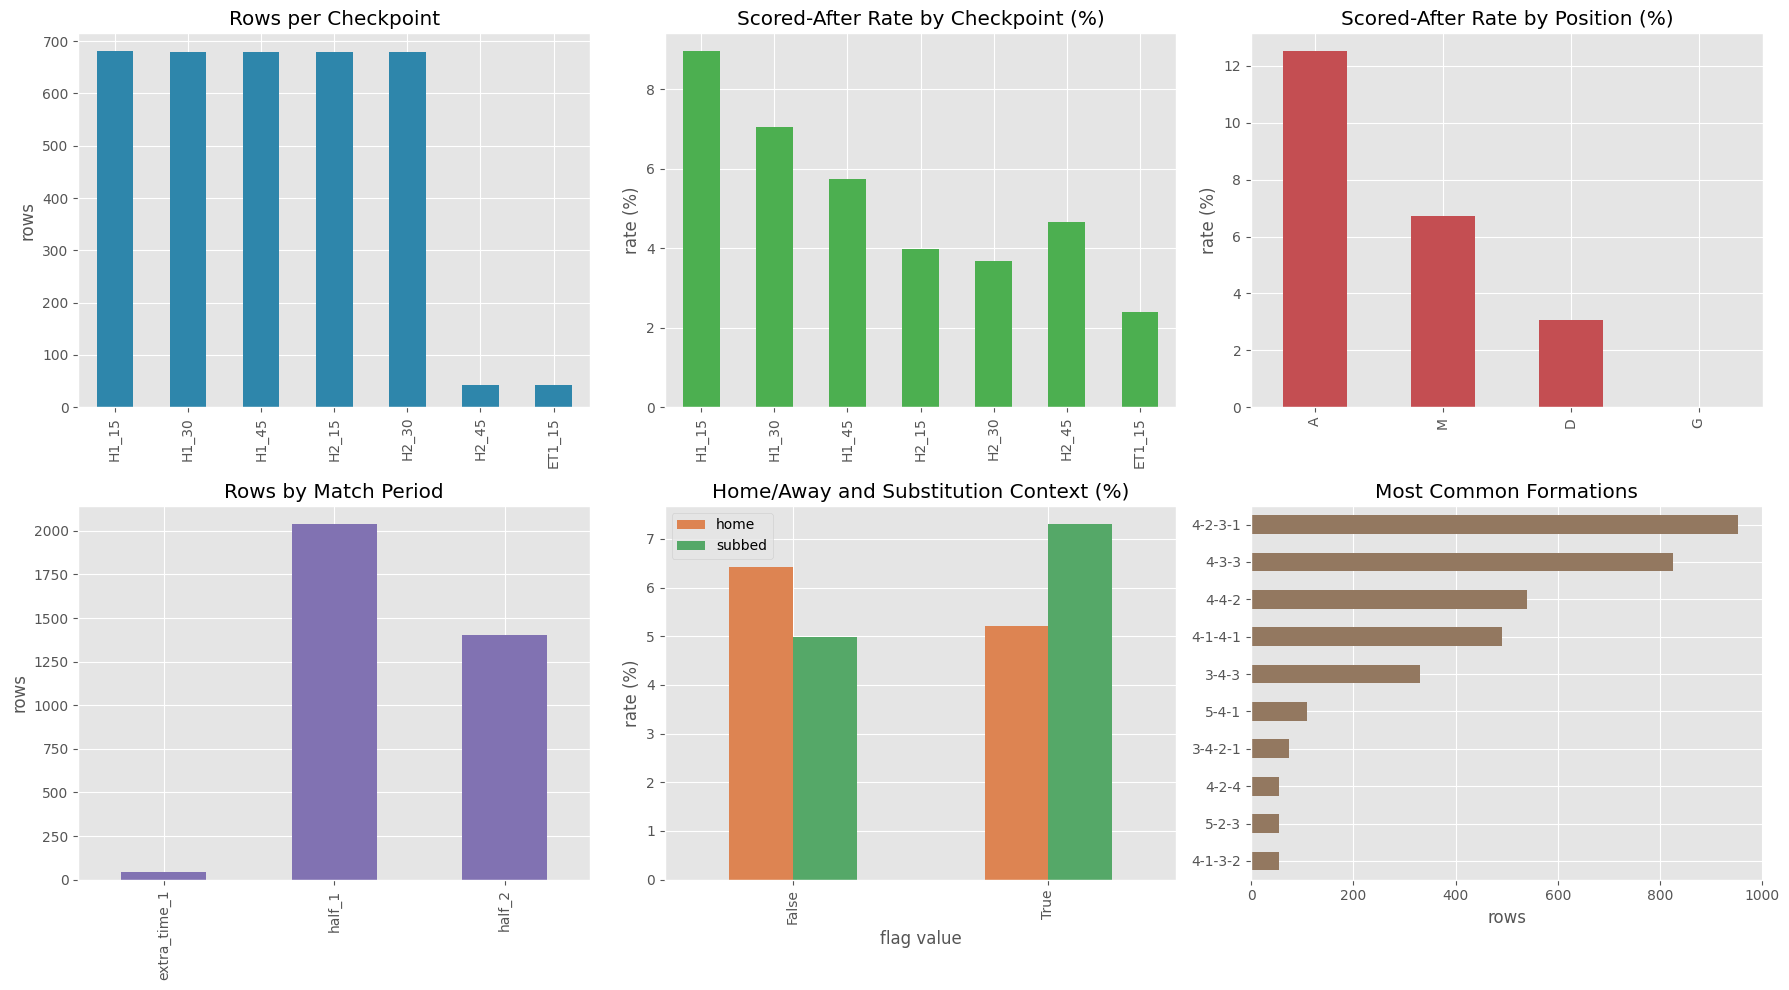

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

main_df.groupby("checkpoint", observed=False).size().plot(
    kind="bar",
    ax=axes[0, 0],
    color="#2E86AB",
)
axes[0, 0].set_title("Rows per Checkpoint")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("rows")

main_df.groupby("checkpoint", observed=False)["scored_after"].mean().mul(100).plot(
    kind="bar",
    ax=axes[0, 1],
    color="#4CAF50",
)
axes[0, 1].set_title("Scored-After Rate by Checkpoint (%)")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("rate (%)")

main_df.groupby("position", observed=False)["scored_after"].mean().mul(100).sort_values(ascending=False).plot(
    kind="bar",
    ax=axes[0, 2],
    color="#C44E52",
)
axes[0, 2].set_title("Scored-After Rate by Position (%)")
axes[0, 2].set_xlabel("")
axes[0, 2].set_ylabel("rate (%)")

main_df.groupby("checkpoint_period", observed=False).size().plot(
    kind="bar",
    ax=axes[1, 0],
    color="#8172B2",
)
axes[1, 0].set_title("Rows by Match Period")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("rows")

context_plot = pd.DataFrame(
    {
        "home": main_df.groupby("is_home")["scored_after"].mean().mul(100),
        "subbed": main_df.groupby("subbed")["scored_after"].mean().mul(100),
    }
)
context_plot.index = [str(index) for index in context_plot.index]
context_plot.plot(kind="bar", ax=axes[1, 1], color=["#DD8452", "#55A868"])
axes[1, 1].set_title("Home/Away and Substitution Context (%)")
axes[1, 1].set_xlabel("flag value")
axes[1, 1].set_ylabel("rate (%)")
axes[1, 1].legend(loc="best")

main_df["formation"].value_counts().head(10).sort_values().plot(
    kind="barh",
    ax=axes[1, 2],
    color="#937860",
)
axes[1, 2].set_title("Most Common Formations")
axes[1, 2].set_xlabel("rows")
axes[1, 2].set_ylabel("")

plt.tight_layout()
plt.show()


## Recent vs. Cumulative Signals

The problem statement explicitly asks whether recent 15-minute behavior or cumulative behavior is more informative, and whether short-term intensity relative to the player's overall level matters.

The next cell turns that into two simple checks:

- compare `last15_*` correlations with their `cumul_*` counterparts
- compute the recent share of each metric (`last15 / cumul`) to see whether late concentration of actions is associated with a higher `scored_after` rate


### `last15_` vs `cumul_` Correlation Comparison

,feature_family,last15_corr,cumul_corr,stronger_signal,abs_corr_gap
4,peak_speed,0.0687,0.0370,last15,0.0317
3,mean_max_speed,0.0617,0.0382,last15,0.0235
1,hsr,0.0534,-0.0316,last15,0.0218
8,shots_top_third,0.0613,0.0500,last15,0.0113
7,shots_under_press,0.0500,0.0395,last15,0.0105
5,shots,0.0598,0.0507,last15,0.0092
0,sprints,0.0279,-0.0209,last15,0.0070
2,distance,0.0028,-0.0120,cumul,-0.0092
6,shots_on_target,0.0363,0.0488,cumul,-0.0126


### Does Recent Share Matter?

,recent_share_ge_50pct,rows,scored_after_rate_pct,feature_family
0,False,1746,4.87,sprints
1,True,1265,7.75,sprints
2,False,2181,4.81,hsr
3,True,1168,8.39,hsr
4,False,2209,4.84,distance
5,True,1154,8.32,distance
6,False,120,0.00,mean_max_speed
7,True,3243,6.26,mean_max_speed
8,False,122,0.00,peak_speed
9,True,3241,6.26,peak_speed


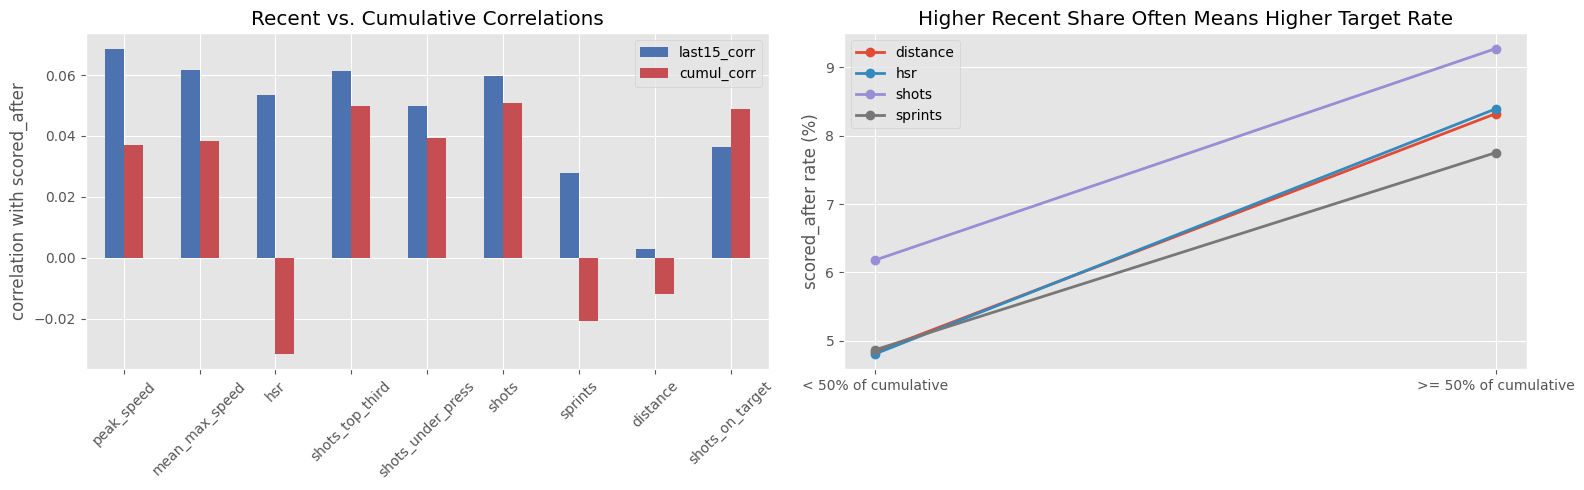

In [7]:
feature_strength_rows = []
recent_share_rows = []

for family, recent_col, cumul_col in feature_families:
    last15_corr = main_df[recent_col].corr(main_df["scored_after"])
    cumul_corr = main_df[cumul_col].corr(main_df["scored_after"])
    feature_strength_rows.append(
        {
            "feature_family": family,
            "last15_corr": last15_corr,
            "cumul_corr": cumul_corr,
            "stronger_signal": "last15" if abs(last15_corr) > abs(cumul_corr) else "cumul",
            "abs_corr_gap": abs(last15_corr) - abs(cumul_corr),
        }
    )

    recent_share = main_df[recent_col] / main_df[cumul_col].replace(0, np.nan)
    subset = main_df.loc[recent_share.notna(), ["scored_after"]].copy()
    subset["high_recent_share"] = recent_share[recent_share.notna()] >= 0.5
    if not subset.empty:
        grouped = subset.groupby("high_recent_share")["scored_after"].agg(["count", "mean"]).reset_index()
        grouped["feature_family"] = family
        grouped["mean"] = (grouped["mean"] * 100).round(2)
        recent_share_rows.append(grouped)

feature_strength = pd.DataFrame(feature_strength_rows).sort_values("abs_corr_gap", ascending=False)
feature_strength[["last15_corr", "cumul_corr", "abs_corr_gap"]] = feature_strength[
    ["last15_corr", "cumul_corr", "abs_corr_gap"]
].round(4)

display(Markdown("### `last15_` vs `cumul_` Correlation Comparison"))
display(feature_strength)

recent_share_effect = pd.concat(recent_share_rows, ignore_index=True)
recent_share_effect = recent_share_effect.rename(
    columns={
        "count": "rows",
        "mean": "scored_after_rate_pct",
        "high_recent_share": "recent_share_ge_50pct",
    }
)
display(Markdown("### Does Recent Share Matter?"))
display(recent_share_effect)

plot_families = ["shots", "sprints", "hsr", "distance"]
plot_df = recent_share_effect[recent_share_effect["feature_family"].isin(plot_families)].copy()
plot_df["recent_share_ge_50pct"] = plot_df["recent_share_ge_50pct"].map({False: "< 50% of cumulative", True: ">= 50% of cumulative"})

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
feature_strength.set_index("feature_family")[["last15_corr", "cumul_corr"]].plot(
    kind="bar",
    ax=axes[0],
    color=["#4C72B0", "#C44E52"],
)
axes[0].set_title("Recent vs. Cumulative Correlations")
axes[0].set_xlabel("")
axes[0].set_ylabel("correlation with scored_after")
axes[0].tick_params(axis="x", rotation=45)

for feature_family, group in plot_df.groupby("feature_family"):
    axes[1].plot(
        group["recent_share_ge_50pct"],
        group["scored_after_rate_pct"],
        marker="o",
        linewidth=2,
        label=feature_family,
    )
axes[1].set_title("Higher Recent Share Often Means Higher Target Rate")
axes[1].set_xlabel("")
axes[1].set_ylabel("scored_after rate (%)")
axes[1].legend(loc="best")

plt.tight_layout()
plt.show()


## Supplementary Tables and Feature Space Extensions

The docs make an important distinction:

- `player_appearance_run.csv` and `player_appearance_shot_limited.csv` already feed the base panel
- `player_appearance_pass.csv` and `player_appearance_behaviour_under_pressure.csv` are **unused** in the base table and are the cleanest source of additional explanatory power
- event tables may contain player appearances that never show up in the checkpoint panel, because the main table includes only players active at defined checkpoints

That means any future join should be built at the **checkpoint level** using event `period` and `minute`, not by attaching full-match aggregates to every checkpoint row.


### Supplementary Table Coverage vs. Main Panel

,table,documented_rows,observed_rows,event_unique_appearances,overlap_with_main_panel,event_only_appearances,main_panel_without_this_event_table
2,player_appearance_run.csv,35133,35133,968,860,108,9
0,player_appearance_pass.csv,29795,29795,959,868,91,1
1,player_appearance_behaviour_under_pressure.csv,12185,12185,923,844,79,25
3,player_appearance_shot_limited.csv,780,780,453,438,15,431


### Candidate Feature Blocks Available for Enrichment

,feature_block,coverage_in_main_appearances_pct,target_rate_when_available_pct,features_in_block
0,pass-derived,99.88,8.76,4
2,run-context-derived,98.96,8.84,5
1,pressure-derived,97.12,9.00,5
3,shot-context-derived,50.40,17.35,5


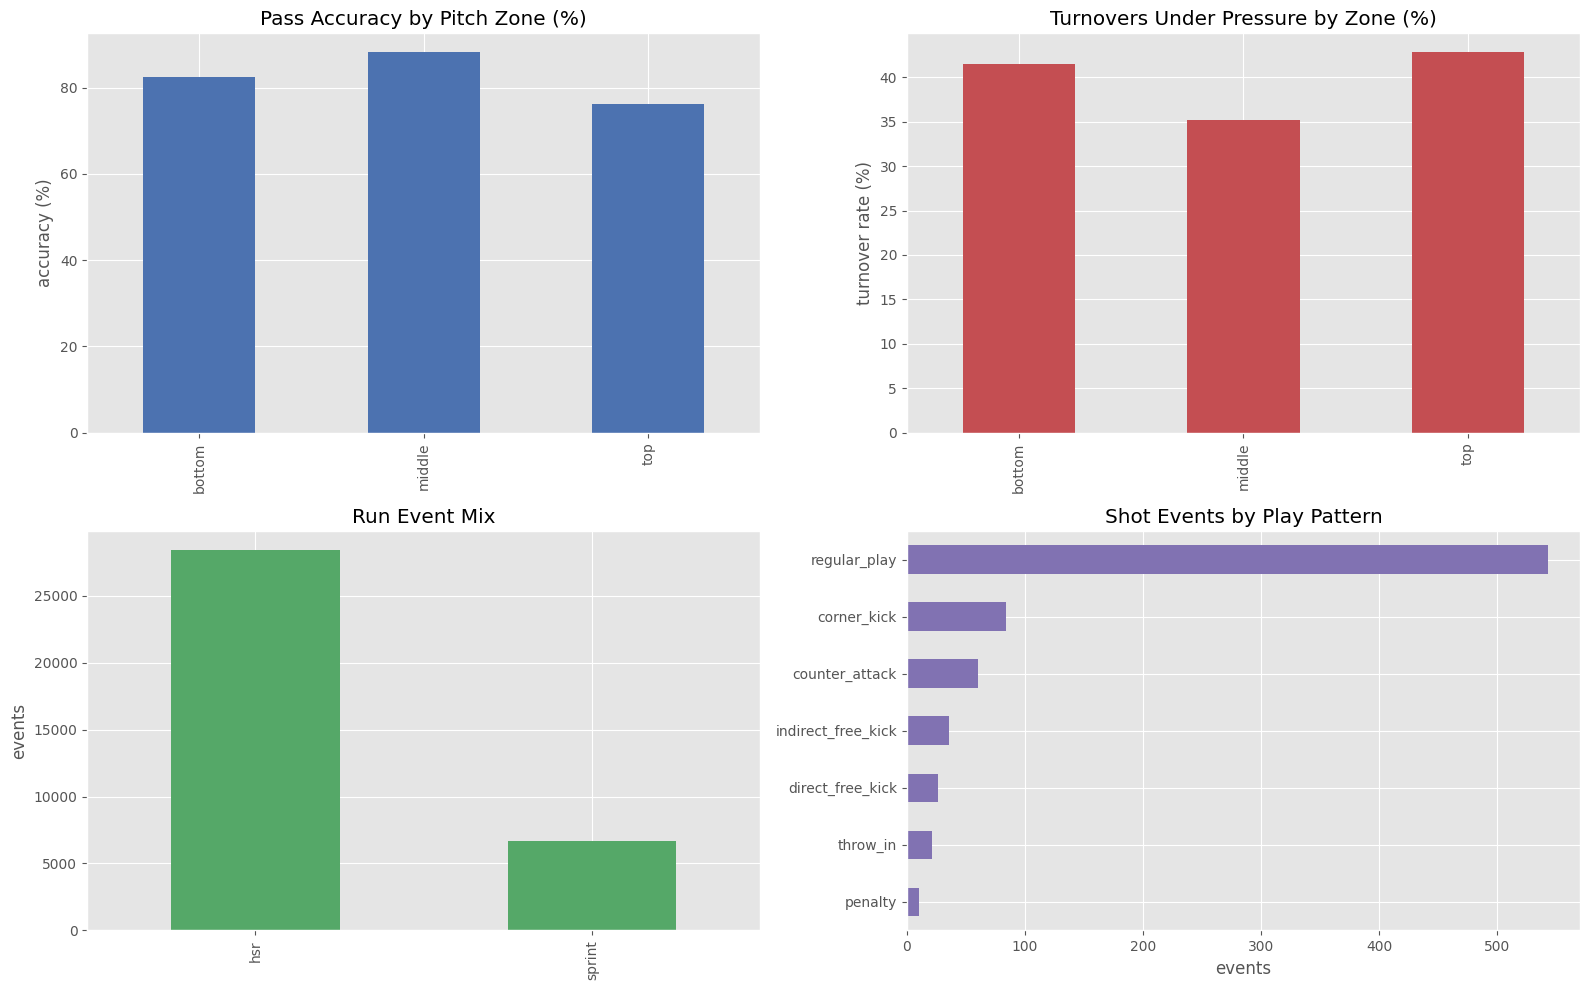

In [8]:
supplementary_docs = {
    "player_appearance_pass.csv": 29795,
    "player_appearance_behaviour_under_pressure.csv": 12185,
    "player_appearance_run.csv": 35133,
    "player_appearance_shot_limited.csv": 780,
}
main_appearance_ids = set(main_df["player_appearance_id"].unique())

supplementary_summary = []
for name, documented_rows in supplementary_docs.items():
    event_df = tables[name]
    event_appearance_ids = set(event_df["player_appearance_id"].dropna().astype(int).unique())
    overlap = len(main_appearance_ids & event_appearance_ids)
    supplementary_summary.append(
        {
            "table": name,
            "documented_rows": documented_rows,
            "observed_rows": len(event_df),
            "event_unique_appearances": len(event_appearance_ids),
            "overlap_with_main_panel": overlap,
            "event_only_appearances": len(event_appearance_ids - main_appearance_ids),
            "main_panel_without_this_event_table": len(main_appearance_ids - event_appearance_ids),
        }
    )

display(Markdown("### Supplementary Table Coverage vs. Main Panel"))
display(pd.DataFrame(supplementary_summary).sort_values("observed_rows", ascending=False))

appearance_base = main_df.groupby("player_appearance_id", observed=False).agg(
    position=("position", "first"),
    checkpoints=("checkpoint", "size"),
    scored_after_any_checkpoint=("scored_after", "max"),
)

passes = tables["player_appearance_pass.csv"].copy()
pass_features = passes.groupby("player_appearance_id").agg(
    passes=("id", "count"),
    pass_accuracy=("accurate", "mean"),
    pass_top_share=("stage", lambda s: (s == "top").mean()),
    no_target_share=("addressee_player_appearance_id", lambda s: s.isna().mean()),
)

pressure = tables["player_appearance_behaviour_under_pressure.csv"].copy()
pressure_features = pressure.groupby("player_appearance_id").agg(
    pressured_events=("id", "count"),
    pressured_accuracy=("accurate", "mean"),
    turnover_rate=("press_induced_outcome", lambda s: (s == "turnover").mean()),
    forward_under_pressure_rate=("press_induced_outcome", lambda s: (s == "forward_pass").mean()),
    mean_pass_angle=("pass_angle", "mean"),
)

runs = tables["player_appearance_run.csv"].copy()
run_features = runs.groupby("player_appearance_id").agg(
    run_events=("id", "count"),
    sprint_share=("run_type", lambda s: (s == "sprint").mean()),
    top_stage_run_share=("stage", lambda s: (s == "top").mean()),
    avg_run_distance=("distance", "mean"),
    avg_max_speed=("max_speed", "mean"),
)

shots = tables["player_appearance_shot_limited.csv"].copy()
shot_features = shots.groupby("player_appearance_id").agg(
    shot_events=("id", "count"),
    shot_under_pressure_rate=("under_pressure", "mean"),
    top_stage_shot_rate=("stage", lambda s: (s == "top").mean()),
    header_rate=("body_part", lambda s: (s == "head").mean()),
    set_piece_rate=(
        "play_pattern",
        lambda s: s.isin(["corner_kick", "direct_free_kick", "indirect_free_kick", "penalty", "throw_in"]).mean(),
    ),
)

candidate_blocks = {
    "pass-derived": pass_features,
    "pressure-derived": pressure_features,
    "run-context-derived": run_features,
    "shot-context-derived": shot_features,
}

feature_block_rows = []
for block_name, feature_df in candidate_blocks.items():
    merged = appearance_base.join(feature_df)
    available = merged[feature_df.columns].notna().any(axis=1)
    feature_block_rows.append(
        {
            "feature_block": block_name,
            "coverage_in_main_appearances_pct": round(available.mean() * 100, 2),
            "target_rate_when_available_pct": round(merged.loc[available, "scored_after_any_checkpoint"].mean() * 100, 2),
            "features_in_block": feature_df.shape[1],
        }
    )

display(Markdown("### Candidate Feature Blocks Available for Enrichment"))
display(pd.DataFrame(feature_block_rows).sort_values("coverage_in_main_appearances_pct", ascending=False))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

passes.groupby("stage")["accurate"].mean().mul(100).reindex(["bottom", "middle", "top"]).plot(
    kind="bar",
    ax=axes[0, 0],
    color="#4C72B0",
)
axes[0, 0].set_title("Pass Accuracy by Pitch Zone (%)")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("accuracy (%)")

pressure.assign(is_turnover=pressure["press_induced_outcome"].eq("turnover")).groupby("stage")["is_turnover"].mean().mul(100).reindex(["bottom", "middle", "top"]).plot(
    kind="bar",
    ax=axes[0, 1],
    color="#C44E52",
)
axes[0, 1].set_title("Turnovers Under Pressure by Zone (%)")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("turnover rate (%)")

runs["run_type"].value_counts().reindex(["hsr", "sprint"]).plot(
    kind="bar",
    ax=axes[1, 0],
    color="#55A868",
)
axes[1, 0].set_title("Run Event Mix")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("events")

shots["play_pattern"].value_counts().head(7).sort_values().plot(
    kind="barh",
    ax=axes[1, 1],
    color="#8172B2",
)
axes[1, 1].set_title("Shot Events by Play Pattern")
axes[1, 1].set_xlabel("events")
axes[1, 1].set_ylabel("")

plt.tight_layout()
plt.show()


## Suggested Next Steps

- Build **checkpoint-aligned** pass and pressure aggregates using event `period` and `minute`, rather than joining full-match totals to every checkpoint row.
- Normalize activity by opportunity: position, minutes available before checkpoint, and whether the player was recently subbed in all clearly matter.
- Keep a strict leakage boundary: the docs explicitly remove shot outcome from the contest table, so any engineered shot features should use only safe context (`body_part`, `technique`, `play_pattern`, `stage`, `under_pressure`).
- Treat the panel structure seriously during modeling. Multiple rows come from the same player appearance and match, so validation should split by `fixture_id` or at least `player_appearance_id`, not by random row.
